# Getting Started Examples

## Most minimal example

In [1]:
import pydocmaker as pyd

doc = pyd.Doc.get_example()
doc.show()


Name,Age,City
John Doe,30,New York
Jane Smith,25,Los Angeles
Mike Johnson,35,Chicago


## Writing a small pydoc


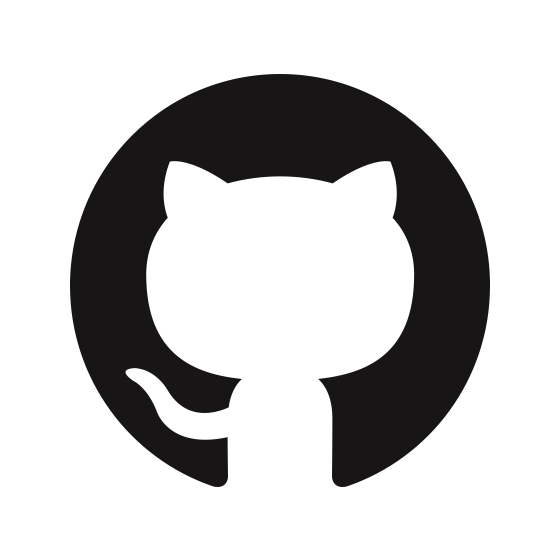

In [2]:

doc = pyd.Doc() # basic doc where we always append to the end
doc.add('dummy text') # adds raw text

# this is how to add parts to the document
doc.add_pre('this will be shown as preformatted') # preformatted
doc.add_md('This is some *fancy* `markdown` **text**') # markdown
doc.add_tex(r'\textbf{Hello, LaTeX!}') # latex

# this is how to add an image from link
doc.add_image("https://github.githubassets.com/assets/GitHub-Mark-ea2971cee799.png", caption='', children='', width=0.8)

doc.show()

## Showing pydocs in iPython/jupyter

the Doc class has a method called show which will detect if it is running in Ipython. If it does it will render the document and show it. 
The desired rendering format can be set with the `engine` argument. Markdown, HTML, or PDF is possible. 

In Ipython or a jupyter notebook:

dummy text



```
this will be shown as preformatted
```

This is some *fancy* `markdown` **text**

```
\textbf{Hello, LaTeX!}
```



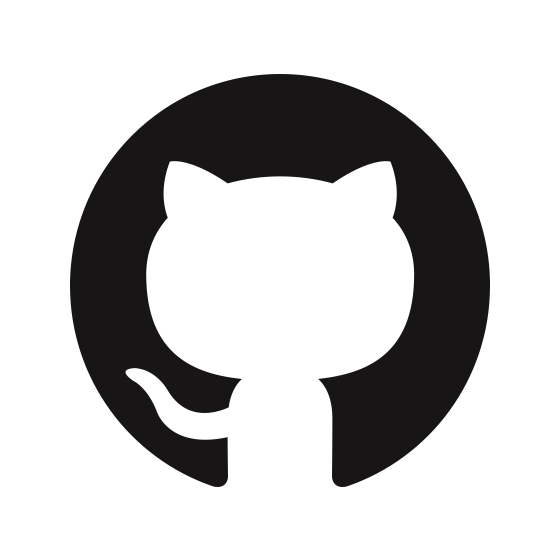

*caption:* None






In [3]:
doc.show('md')


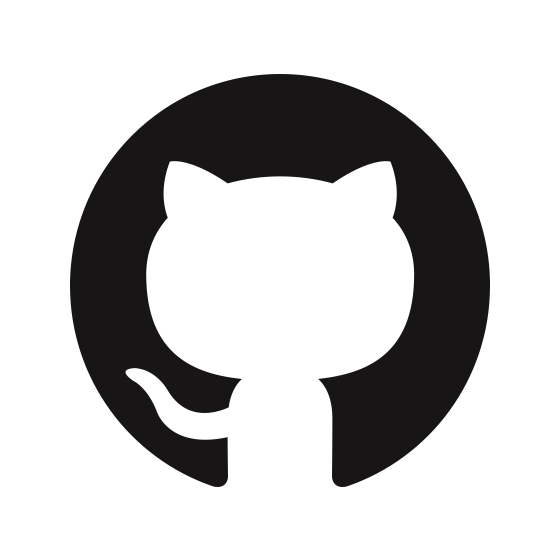

In [4]:
doc.show('html')

Or (**NOTE**: some IDEs do not support this and instead open a "save" dialog, but in a browser with jupyter this works): 

In [5]:
# doc.show('pdf') # this is commented out since within automatically generated documentation for this library it dows not work. 

## Exporting pydocs to common formats

export via:

In [6]:
import os
# some dir to write my example files to
os.makedirs('../exported_docs_examples', exist_ok=True)

In [7]:
# returns string
text_html = doc.export('html')

In [8]:

# or write a file
doc.export('html', '../exported_docs_examples/outfile.html')

True

Or alternatively:

In [9]:
doc.to_html('../exported_docs_examples/outfile.html') # will write a HTML file
doc.to_pdf('../exported_docs_examples/outfile.zip') # will write the whole latex project dir as a pdf file
doc.to_markdown('../exported_docs_examples/outfile.md') # will write a Markdown file
doc.to_docx('../exported_docs_examples/outfile.docx') # will write a docx file
doc.to_textile('../exported_docs_examples/outfile.textile.zip') # will pack all textile files and write them to a zip archive
doc.to_tex('../exported_docs_examples/outfile.tex.zip') # will pack all tex files and write them to a zip archive
doc.to_ipynb('../exported_docs_examples/outfile.ipynb') # will write a ipynb file

doc.to_json('../exported_docs_examples/outfile.json') # saves the document

Running with latex_compiler='pdflatex'
Writing file: 1769523338_mydocument.tex
Writing file: GitHub-Mark-ea2971cee799.png
Writing file: doc.json
Compilation run 1
Compilation run 2
Compilation run 3
Zipping folder to bytes: C:\Users\tglaubach\AppData\Local\Temp\tmpgjug6h1i
Saved to path_or_stream="../exported_docs_examples/outfile.zip" with function "make_pdf_zip"


True

### Exporting to PDFs (via pandoc, LaTeX, Word, or Libreoffice)

In [10]:
# will write a PDF file using pandoc (fastest, most robust, but very limited formatting options)
doc.to_pdf('../exported_docs_examples/outfile_pdf_pandoc.pdf', engine="pandoc") 

Saved to path_or_stream="../exported_docs_examples/outfile_pdf_pandoc.pdf" with function "to_pdf_pandoc"


True

In [11]:
# will write a PDF file using any installed pdflatex compiler
doc.to_pdf('../exported_docs_examples/outfile_pdf_latex.pdf', engine="tex")

Running with latex_compiler='pdflatex'
Writing file: 1769523343_mydocument.tex
Writing file: GitHub-Mark-ea2971cee799.png
Compilation run 1
Compilation run 2
Compilation run 3
Reading PDF to bytes: C:\Users\tglaubach\AppData\Local\Temp\tmpfioap5s7
Saved to path_or_stream="../exported_docs_examples/outfile_pdf_latex.pdf" with function "make_pdf"


True

In [12]:
# will write a PDF file using Microsoft Word (only works on windows with win32com and word installed)
doc.to_pdf('../exported_docs_examples/outfile_pdf_word.pdf', engine="tex")

Running with latex_compiler='pdflatex'
Writing file: 1769523345_mydocument.tex
Writing file: GitHub-Mark-ea2971cee799.png
Compilation run 1
Compilation run 2
Compilation run 3
Reading PDF to bytes: C:\Users\tglaubach\AppData\Local\Temp\tmpja7cmum0
Saved to path_or_stream="../exported_docs_examples/outfile_pdf_word.pdf" with function "make_pdf"


True

In [13]:
# will write a PDF file using Libreoffice
doc.to_pdf('../exported_docs_examples/outfile_pdf_libreoffice.pdf', engine="tex")

Running with latex_compiler='pdflatex'
Writing file: 1769523348_mydocument.tex
Writing file: GitHub-Mark-ea2971cee799.png
Compilation run 1
Compilation run 2
Compilation run 3
Reading PDF to bytes: C:\Users\tglaubach\AppData\Local\Temp\tmpgegv8_ky
Saved to path_or_stream="../exported_docs_examples/outfile_pdf_libreoffice.pdf" with function "make_pdf"


True

## Add ``pyplot`` Figures to your pydoc

say you have a figure like below

Text(0.5, 0.5, 'watermark')

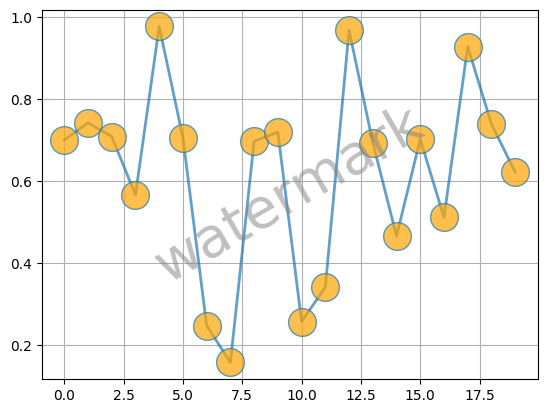

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)


fig, ax = plt.subplots()
ax.plot(np.random.rand(20), '-o', ms=20, lw=2, alpha=0.7, mfc='orange')
ax.grid()

ax.text(0.5, 0.5, 'watermark', transform=ax.transAxes,
        fontsize=40, color='gray', alpha=0.5,
        ha='center', va='center', rotation=30)

you can embed it in your document like this:


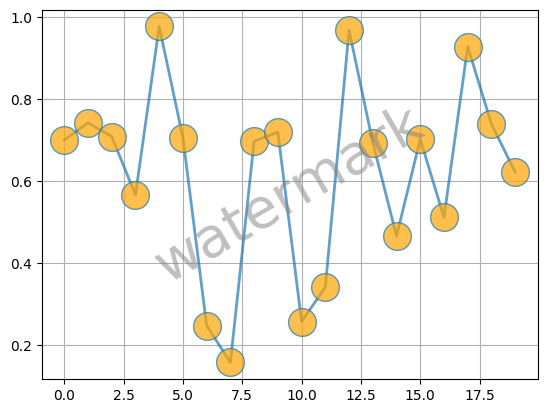

In [15]:
doc = pyd.Doc()
doc.add("this is how to embed a figure from pyplot to your document")

# this is how to embed a pyplot figure in your document
doc.add_image(fig, caption='test figure')
# this is equivalent
# doc.add_fig(fig, caption='test figure')


doc.show()

you can also just add the last figure which was generated (pyplots `gfc()`) by omitting the fig argument. 

Lets first generate a random figure to include and then add it to our document



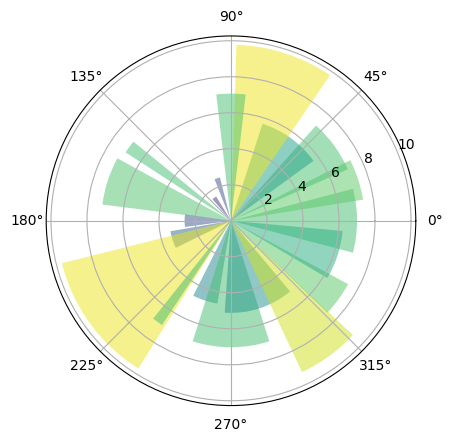

In [16]:
# Fixing random state for reproducibility
np.random.seed(19680801)

# Compute pie slices
N = 20
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
radii = 10 * np.random.rand(N)
width = np.pi / 4 * np.random.rand(N)
colors = plt.cm.viridis(radii / 10.)

ax = plt.subplot(projection='polar')
ax.bar(theta, radii, width=width, bottom=0.0, color=colors, alpha=0.5)


doc = pyd.Doc()
doc.add("this is how to add the last matplotlib figure to your document")

# this is how to add the last pyplot figure as image
doc.add_fig(caption='last figure')

doc.show()

plt.close() # prevents the plot from showing up as a pyplot figure in this notebook

## Add an image from a numpy array

**NOTE**: This needs the PIL library installed!


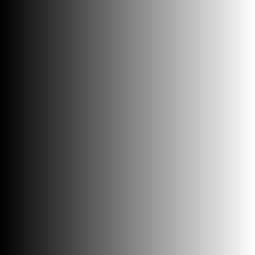

In [17]:
# make a dummy image (numpy array)
m = [np.arange(255).astype(np.uint8).tolist() for i in range(255)]
m = np.array(m, dtype=np.uint8)
plt.imshow(m, cmap='gray')

doc = pyd.Doc()
doc.add_image(m, caption = 'numpy generated image', width=0.8)
doc.show()


plt.close() # prevents the plot from showing up as a pyplot figure in this notebook

## pydoc to python list


A pydoc document is just a list of dicts. (For details see the other examples). In case you want to transform your pydoc document to a generic python list of dicts just use `.dump()`

In [18]:
doc = pyd.Doc().add_md("Dummy Text").add_pre("Dummy preformatted text")
doc.dump()

[{'typ': 'markdown', 'children': 'Dummy Text', 'color': '', 'end': None},
 {'typ': 'verbatim',
  'children': 'Dummy preformatted text',
  'color': '',
  'end': None}]

## Storing metadata

You can store any data within your pydoc without it getting rendered. This is done in a meta field. 

**NOTE**: Whatever you save you should stick to the base python types of list, dict, string, float int, or make sure its json serializeable in order to avoid errors. Nested dicts are perfectly fine as well

In [19]:
doc = pyd.Doc()

# this will not get rendered
doc.add_meta({'doc_name': 'test'}) # either like this
doc.add_meta(author='Franz Kafka') # or like this. 

# nested dicts work fine as well
doc.add_meta(testdata={'index':[1,2,3], 'columns': {'c1': [4,5,6], 'c2': [7,8,9]}})

# this will get rendered
doc.add_md("My dummy text")
doc.show() # show the document in order to show, that nothing of the data we added gets rendered

# show the underlying datastructure to show the data is there
doc.dump()

[{'typ': 'meta',
  'children': '',
  'data': {'doc_name': 'test',
   'author': 'Franz Kafka',
   'testdata': {'index': [1, 2, 3],
    'columns': {'c1': [4, 5, 6], 'c2': [7, 8, 9]}}}},
 {'typ': 'markdown', 'children': 'My dummy text', 'color': '', 'end': None}]

**NOTE**: The call `.add_meta` will create a metadata element if it does not exist. If it does, it will add to the first `meta` element it finds. 

You can get the metadata within your document like this:

In [20]:
doc.get_metadata()

{'doc_name': 'test',
 'author': 'Franz Kafka',
 'testdata': {'index': [1, 2, 3],
  'columns': {'c1': [4, 5, 6], 'c2': [7, 8, 9]}}}

since this creates a new empty dict in case no metadat is found you should not work with this dict directly, but rather use the `.add_meta` method from above to change the metadata.

## Adding a table

In [21]:
doc = pyd.Doc()
rows = []
colors = ['blue', 'red', 'green']
for irow in range(3):
    row = [pyd.mk_md(f'Row {irow} Col {icol}', color=colors[icol]) for icol in range(3)]
    rows.append(row)

doc.add_table(rows, header=['Blue Text', 'Red Text', 'Green Text'])
doc.show()        

Blue Text,Red Text,Green Text
Row 0 Col 0,Row 0 Col 1,Row 0 Col 2
Row 1 Col 0,Row 1 Col 1,Row 1 Col 2
Row 2 Col 0,Row 2 Col 1,Row 2 Col 2


Note: maybe within the pydocmaker documentation the colors will niot be shown correctly, but within jupyter and real documents this works. 

## Configuring/testing PDF engines

you can get info on what is available and currently configured in pydocmaker via the following convenience function

In [22]:
pyd.info_optionals()

{'can_run_pandoc': True,
 'can_use_w32_word': True,
 'can_use_libreoffice': True,
 'pdf_engines_available': ['tex', 'word', 'libreoffice', 'pandoc'],
 'pdf_engine': 'tex',
 'libreoffice_path': 'C:\\Program Files\\LibreOffice\\program\\soffice.exe'}

you can change parameters in the config (for the current session only!) using the methods starting with `pyd.config_`

In [23]:
p = pyd.config_libreoffice_path_get()
p

'C:\\Program Files\\LibreOffice\\program\\soffice.exe'

In [24]:
pyd.config_libreoffice_path_set(p)

'C:\\Program Files\\LibreOffice\\program\\soffice.exe'

In [25]:
e = pyd.config_pdf_engine_get()
e

'tex'

In [26]:
pyd.config_pdf_engine_set(e)

'tex'

In [27]:
# tests the currently configured default pdf engine
pyd.config_pdf_engine_test()

'pdflatex'

In [28]:
# searches the system for all available pdf engines and returns them as strings
pyd.config_pdf_engine_scan()

['tex', 'word', 'libreoffice', 'pandoc']